In [12]:
import pandas as pd
import os

# Ruta al archivo (ajustada a la salida real del script modificado)
csv_path = '../optimization/rapports/benchmark_onnx_latences.csv'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    # Validamos que la columna se llame 'latence_ms'
    if 'latence_ms' not in df.columns and not df.empty:
        # Si el CSV no tiene cabecera, la renombramos
        df.columns = ['latence_ms']
    print(f"✅ Datos cargados: {len(df)} muestras encontradas.")
else:
    print(f"❌ Error: No se encuentra {csv_path}. CWD actual: {os.getcwd()}")

✅ Datos cargados: 500 muestras encontradas.


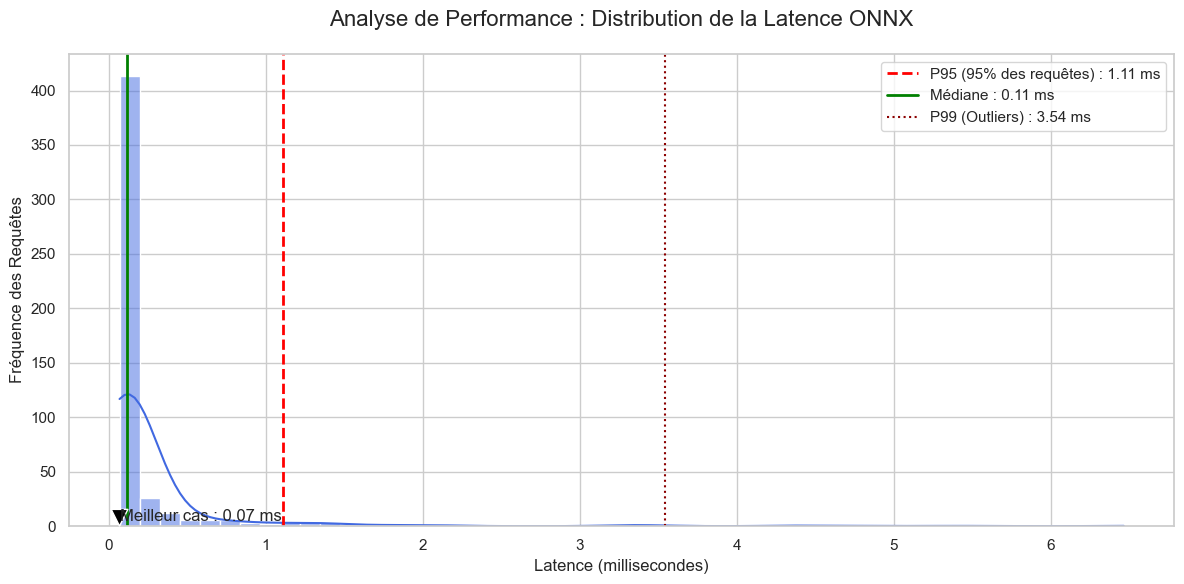

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique professionnelle
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Histogramme avec courbe de densité (KDE)
sns.histplot(df['latence_ms'], bins=50, kde=True, color='royalblue', edgecolor='white')

# Calcul des métriques pour les lignes de référence
p95 = df['latence_ms'].quantile(0.95)
p99 = df['latence_ms'].quantile(0.99)
mediana = df['latence_ms'].median()

# Tracer les lignes de référence
plt.axvline(p95, color='red', linestyle='--', linewidth=2, label=f'P95 (95% des requêtes) : {p95:.2f} ms')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Médiane : {mediana:.2f} ms')

# Optionnel : Ajouter le P99 s'il y a beaucoup de dispersion
if p99 > p95 * 1.5:
    plt.axvline(p99, color='darkred', linestyle=':', label=f'P99 (Outliers) : {p99:.2f} ms')

# Titres et labels
plt.title('Analyse de Performance : Distribution de la Latence ONNX', fontsize=16, pad=20)
plt.xlabel('Latence (millisecondes)', fontsize=12)
plt.ylabel('Fréquence des Requêtes', fontsize=12)
plt.legend(frameon=True, loc='upper right')

# Annotation pour le point optimal
plt.annotate(f'Meilleur cas : {df["latence_ms"].min():.2f} ms', 
             xy=(df['latence_ms'].min(), 0), xytext=(df['latence_ms'].min(), 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

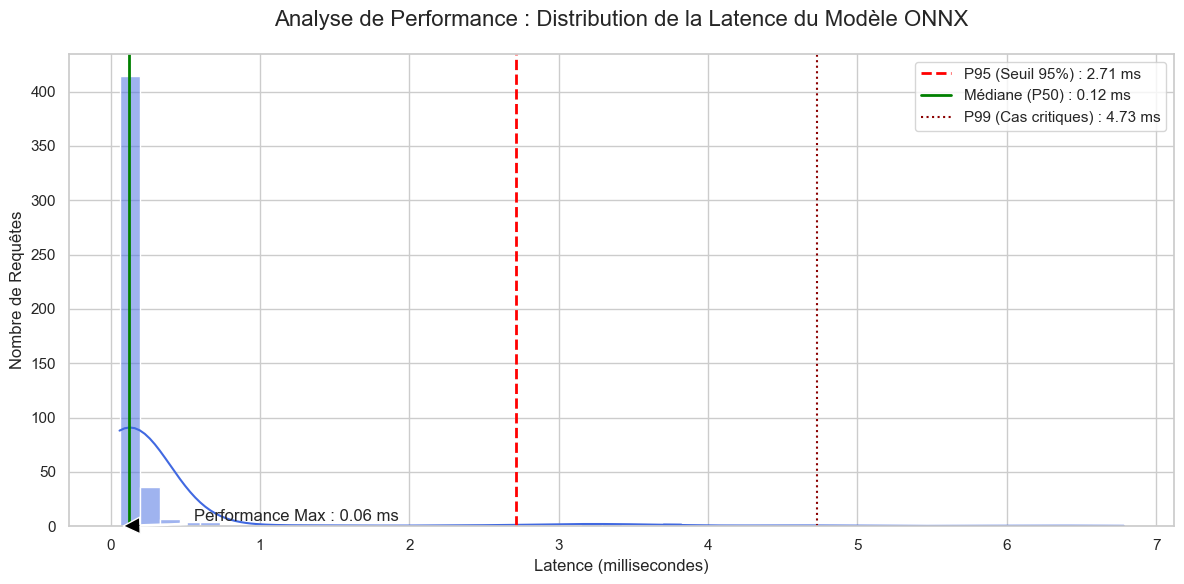

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique pour un rendu professionnel
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Histogramme avec courbe de densité (KDE)
# Le KDE permet de visualiser la fluidité de la distribution
sns.histplot(df['latence_ms'], bins=50, kde=True, color='royalblue', edgecolor='white')

# Calcul des métriques de performance
p95 = df['latence_ms'].quantile(0.95)
p99 = df['latence_ms'].quantile(0.99)
mediane = df['latence_ms'].median()

# Ajout des lignes de référence (Seuils critiques)
plt.axvline(p95, color='red', linestyle='--', linewidth=2, label=f'P95 (Seuil 95%) : {p95:.2f} ms')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Médiane (P50) : {mediana:.2f} ms')

# Affichage du P99 uniquement s'il y a des pics de latence importants
if p99 > p95 * 1.5:
    plt.axvline(p99, color='darkred', linestyle=':', label=f'P99 (Cas critiques) : {p99:.2f} ms')

# Titres et étiquettes en français
plt.title('Analyse de Performance : Distribution de la Latence du Modèle ONNX', fontsize=16, pad=20)
plt.xlabel('Latence (millisecondes)', fontsize=12)
plt.ylabel('Nombre de Requêtes', fontsize=12)
plt.legend(frameon=True, loc='upper right')

# Annotation pour souligner la performance maximale
plt.annotate(f'Performance Max : {df["latence_ms"].min():.2f} ms', 
             xy=(df['latence_ms'].min(), 0), xytext=(df['latence_ms'].min() + 0.5, 5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

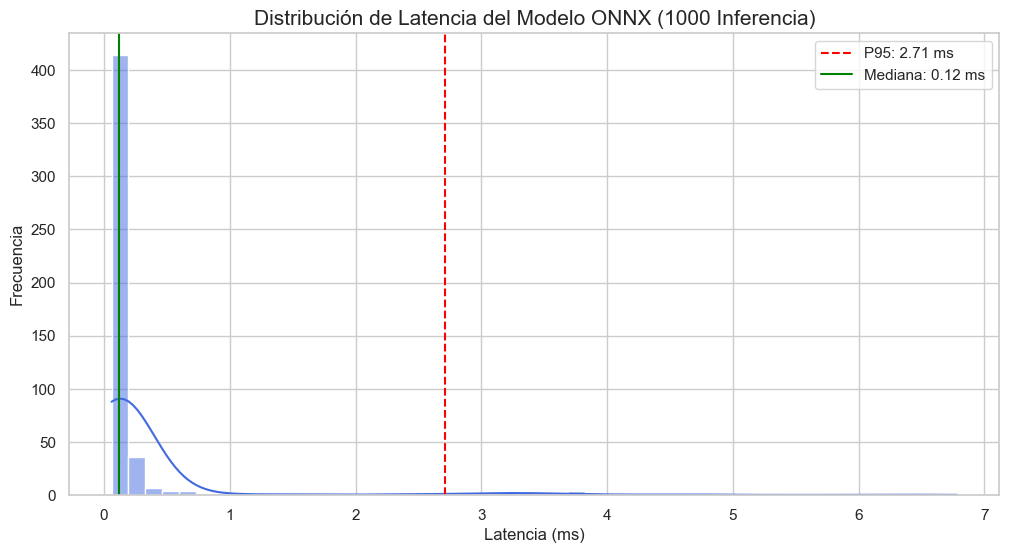

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Histograma con curva de densidad
sns.histplot(df['latence_ms'], bins=50, kde=True, color='royalblue')

# Líneas de referencia para Percentiles Críticos
p95 = df['latence_ms'].quantile(0.95)
plt.axvline(p95, color='red', linestyle='--', label=f'P95: {p95:.2f} ms')
plt.axvline(df['latence_ms'].median(), color='green', linestyle='-', label=f'Mediana: {df["latence_ms"].median():.2f} ms')

plt.title('Distribución de Latencia del Modelo ONNX (1000 Inferencia)', fontsize=15)
plt.xlabel('Latencia (ms)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()